# 🎯 Project Goal
---
#### Collaborators: Amy Zhang; ChatGPT
---
The goal of this project is to train a **Random Forest** model to determine:

- Which **weather stations** (out of 15)
- And which **weather features** (temperature, humidity, etc.)

...are the most useful in predicting whether a day will be **pleasant** or **unpleasant**.

---

### Why Use a Random Forest?

Random forests are an ensemble of decision trees that are well-suited for **tabular data** and **classification tasks** like this one.

Unlike CNNs and RNNs, which rely on spatial or temporal structure and are part of the deep learning family, **random forests are *not* deep learning**. Instead, they fall under **ensemble learning**, offering high interpretability and robust performance with minimal preprocessing.

A key strength of random forests is their ability to provide clear **feature importances**, showing which inputs are most predictive — essentially surfacing the model’s internal value hierarchy.

This kind of insight is especially valuable in high-stakes, resource-sensitive contexts, like addressing climate change. In fact, in a previous project where we ranked U.S. states by influenza urgency, a model like this might have been particularly well-suited for guiding public health decisions.


---

### How This Problem Was Framed with Other Models:

- **CNN (Convolutional Neural Network):**  
  Predicted pleasant/unpleasant **across all 15 weather stations** at a **single time step (day)**.  
  Inputs were structured like a **grid**:  
  **Shape** → `(samples, stations, features)`

- **RNN (Recurrent Neural Network):**  
  Predicted pleasant/unpleasant on **Day 8**, using weather data from **Days 1–7** at a single station.  
  Inputs were **sequences**:  
  **Shape** → `(samples, time_steps, features)`

- **Random Forest:**  
  Takes a "flat" table of features and targets.  
  It doesn't care about spatial (CNN) or sequential (RNN) structure.  
  **Input shape** →  
  - `X`: `(n_days, n_features)`  
  - `y`: `(n_days,)`



# 1. Import Libraries and Datasets

In [1]:
# 📊 Data manipulation and analysis
import pandas as pd          # Tabular data handling
import numpy as np           # Numerical operations

# 📈 Visualization
import seaborn as sns        # For visualizations (e.g., heatmaps, bar plots)
import matplotlib.pyplot as plt  # Core plotting library

# 🗂️ File operations
import os                    # For file system tasks (e.g., saving figures)

# 🔧 Utility functions
import operator              # For functional tools (e.g., sorting feature importances)

# 🎯 Model building: Random Forest
from sklearn.ensemble import RandomForestClassifier   # Our model
from sklearn.tree import plot_tree                    # For plotting individual decision trees
from sklearn.metrics import accuracy_score            # For model evaluation

# 🧪 Data splitting
from sklearn.model_selection import train_test_split  # Split data into training/test sets

# 🔒 Reproducibility
np.random.seed(42)


In [2]:
weather_df = pd.read_csv('Dataset-weather-prediction-dataset-processed.csv')

In [3]:
# Import 'pleasant_weather'
pleasant_weather = pd.read_csv('pleasant_weather_Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv')

# PART I. Random Forest on Full Dataset

# 2. Dataset Clean & Prep for ML
🧐 NOTE:
> Prior assignment directed exporting a version of the dataset without the 'DATE' column. However, this project requires filtering by decade — which is impossible without a time index. Adjusting here by reloading the full version with dates to support temporal slicing.


In [4]:
# Drop all columns that start with TOURS_, ROMA_, or GDANSK_
weather_df = weather_df.drop(columns=[
    col for col in weather_df.columns
    if col.startswith('TOURS_') or col.startswith('ROMA_') or col.startswith('GDANSK_')
])


In [5]:
# Drop all columns that end with '_snow_depth' and '_wind_speed'
weather_df = weather_df.drop(columns=[
    col for col in weather_df.columns
    if col.endswith('_snow_depth') or col.endswith('_wind_speed')
])


In [6]:
### Copy LJUBLJANA_cloud_cover → assign as KASSEL_cloud_cover
### Copy SONNBLICK_pressure → assign as MUNCHENB_pressure
### Copy OSLO_humidity → assign as STOCKHOLM_humidity

# Fill in the missing columns using nearby station data
weather_df['KASSEL_cloud_cover'] = weather_df['LJUBLJANA_cloud_cover']
weather_df['MUNCHENB_pressure'] = weather_df['SONNBLICK_pressure']
weather_df['STOCKHOLM_humidity'] = weather_df['OSLO_humidity']


In [7]:
weather_df.shape

(22950, 137)

In [8]:
list(pleasant_weather.columns)

['DATE',
 'BASEL_pleasant_weather',
 'BELGRADE_pleasant_weather',
 'BUDAPEST_pleasant_weather',
 'DEBILT_pleasant_weather',
 'DUSSELDORF_pleasant_weather',
 'HEATHROW_pleasant_weather',
 'KASSEL_pleasant_weather',
 'LJUBLJANA_pleasant_weather',
 'MAASTRICHT_pleasant_weather',
 'MADRID_pleasant_weather',
 'MUNCHENB_pleasant_weather',
 'OSLO_pleasant_weather',
 'SONNBLICK_pleasant_weather',
 'STOCKHOLM_pleasant_weather',
 'VALENTIA_pleasant_weather']

In [9]:
# Export to CSV
weather_df.to_csv('weather_ACTUAL_CLEANED.csv', index=False)


In [10]:
pleasant_weather.shape

(22950, 16)

In [14]:
# Import unmelted long-form to find most consistent decades
unmelt_df = pd.read_csv('weather_data_post_unmelt.csv')

In [16]:
# Import unmelted long-form to find most consistent decades
pleasant_unmelt_df = pd.read_csv('pleasant_weather_post_unmelt.csv')

In [17]:
unmelt_df.columns

Index(['date', 'date_parsed', 'year', 'month', 'day_name', 'weatherstation',
       'country', 'cloud_cover', 'global_radiation', 'humidity',
       'precipitation', 'pressure', 'snow_depth', 'sunshine', 'temp_max',
       'temp_mean', 'temp_min', 'wind_speed'],
      dtype='object')

In [18]:
pleasant_unmelt_df.columns

Index(['date', 'date_parsed', 'year', 'day_name', 'weatherstation', 'country',
       'weatherstation_country', 'pleasant_weather'],
      dtype='object')

In [19]:
### Merge the two dataframes
df = pd.merge(unmelt_df, pleasant_unmelt_df[['date', 'pleasant_weather']], on='date', how='inner')


In [20]:
### Create a decade column
df['decade'] = (df['year'] // 10) * 10


In [23]:
daily_counts = (
    df.groupby(['decade', 'weatherstation', 'date'])
    .size()
    .reset_index(name='obs_per_day')
)

# Now count how many days we have per station per decade:
station_decade_daycounts = (
    daily_counts.groupby(['decade', 'weatherstation'])
    .size()
    .reset_index(name='day_count')
)


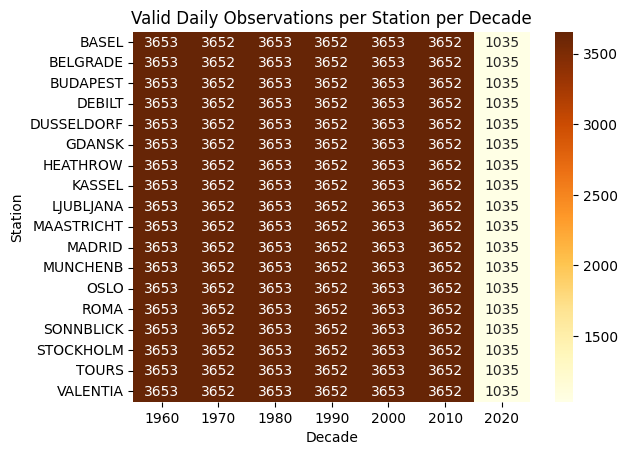

In [24]:
pivot = station_decade_daycounts.pivot(index='weatherstation', columns='decade', values='day_count')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrBr')
plt.title("Valid Daily Observations per Station per Decade")
plt.xlabel("Decade")
plt.ylabel("Station")
plt.show()


In [26]:
# Convert date to datetime and extract decade
weather_df['date'] = pd.to_datetime(weather_df['DATE'], format="%Y%m%d")
weather_df['year'] = weather_df['date'].dt.year
weather_df['decade'] = (weather_df['year'] // 10) * 10


In [32]:
### Select for 2010s
weather_2010s = weather_df[weather_df['decade'] == 2010].copy()


In [31]:
pleasant_weather['date'] = pd.to_datetime(pleasant_weather['DATE'], format="%Y%m%d")
pleasant_weather['year'] = pleasant_weather['date'].dt.year
pleasant_weather['decade'] = (pleasant_weather['year'] // 10) * 10


In [34]:
pleasant_2010s = pleasant_weather[pleasant_weather['decade'] == 2010].copy()


In [35]:
### Make sure their date indexes align.

weather_2010s = weather_2010s.sort_values('date').reset_index(drop=True)
pleasant_2010s = pleasant_2010s.sort_values('date').reset_index(drop=True)


In [36]:
weather_2010s.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,MUNCHENB_pressure,STOCKHOLM_humidity,date,year,decade
0,20100101,1,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,...,6.0,1.7,-1.6,5.0,8,1.0054,0.76,2010-01-01,2010,2010
1,20100102,1,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,...,6.0,0.8,-4.5,6.2,8,1.0250,0.74,2010-01-02,2010,2010
2,20100103,1,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,...,1.6,0.5,-4.1,5.1,1,1.0404,0.84,2010-01-03,2010,2010
3,20100104,1,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,...,6.5,3.7,1.3,3.8,6,1.0316,0.89,2010-01-04,2010,2010
4,20100105,1,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,...,4.7,2.3,-0.7,5.4,8,1.0206,0.78,2010-01-05,2010,2010


In [37]:
pleasant_2010s.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather,date,year,decade
0,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010-01-01,2010,2010
1,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010-01-02,2010,2010
2,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010-01-03,2010,2010
3,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010-01-04,2010,2010
4,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2010-01-05,2010,2010


# 👎 What the instructions probably wanted — but didn't say clearly:

> The first big model uses all stations' features per day.

- The target is whether the day is pleasant or not **in general** (i.e., some kind of consensus or overall pleasantness).

- Feature importances from this model help identify which stations contribute most to predicting pleasantness.

- Then, separate models are run for each of the top stations individually, allowing finer-grained analysis.

**Note:** The instructions do not explicitly clarify this, leading to confusion around how to structure the target variable and data shapes.


# 3. Implementing Random Forest on the Full Dataset

## 🔍 Model Evaluation
- Accuracy: ~97%
- Top 3 weather stations most influential in predicting weather pleasantness:
1) Madrid
2) Budapest
3) Ljubljana

> Madrid ranking highest is expected, given its stable Mediterranean climate and — crucially — its disproportionately large share of the minority class (pleasant days), making it particularly valuable for distinguishing between classes.

In [44]:
# 1. Prepare features (X)
# Drop columns not needed for modeling
X = weather_2010s.drop(columns=['DATE', 'date', 'year', 'decade', 'MONTH'])

# 2. Prepare target (y)
# Collapse all stations' pleasantness columns into a single boolean per day
pleasant_cols = [col for col in pleasant_2010s.columns if '_pleasant_weather' in col]
y = pleasant_2010s[pleasant_cols].any(axis=1).astype(int)

# 3. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train random forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest accuracy (all stations): {accuracy:.3f}")

# 6. Feature importances
importances = clf.feature_importances_

# 7. Reshape importances to (15 stations, 9 features each)
important_reshaped = importances.reshape(-1, 15, 9)

# 8. Sum importances per station (axis=2 sums features for each station)
station_importances = important_reshaped.sum(axis=2)[0]

Random Forest accuracy (all stations): 0.967


In [54]:
print(X.shape)  # Should be (n_samples, 135)
print(importances.shape)  # Should be (135,)


(3652, 135)
(135,)


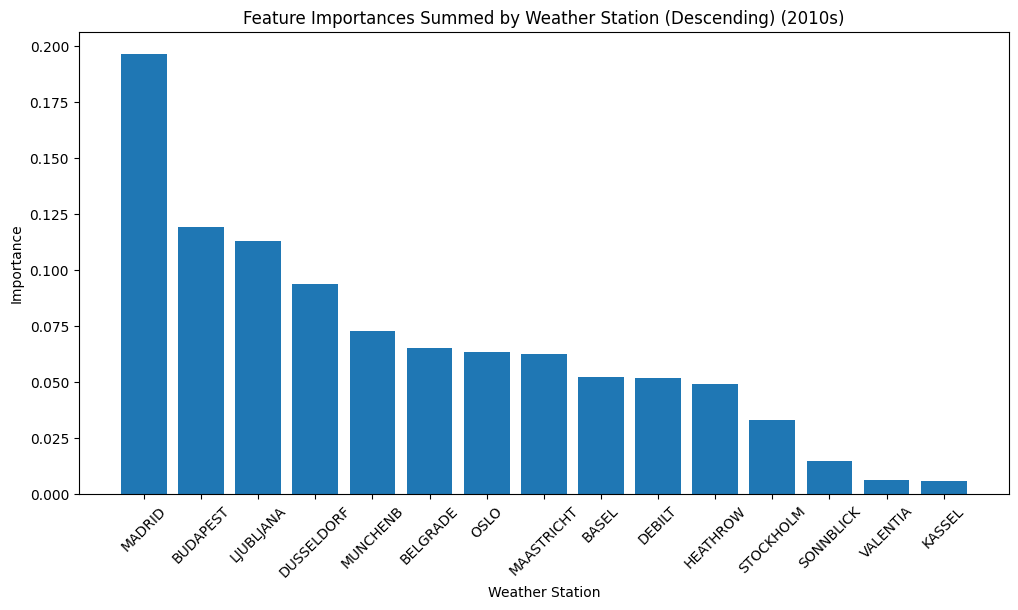

In [46]:
stations = [col.split('_')[0] for col in pleasant_cols]

# Sort indices by descending importance
sorted_idx = np.argsort(station_importances)[::-1]

# Apply sorting to stations and importances
stations_sorted = [stations[i] for i in sorted_idx]
importances_sorted = station_importances[sorted_idx]

plt.figure(figsize=(12, 6))
plt.bar(stations_sorted, importances_sorted)
plt.title('Feature Importances Summed by Weather Station (Descending) (2010s)')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()


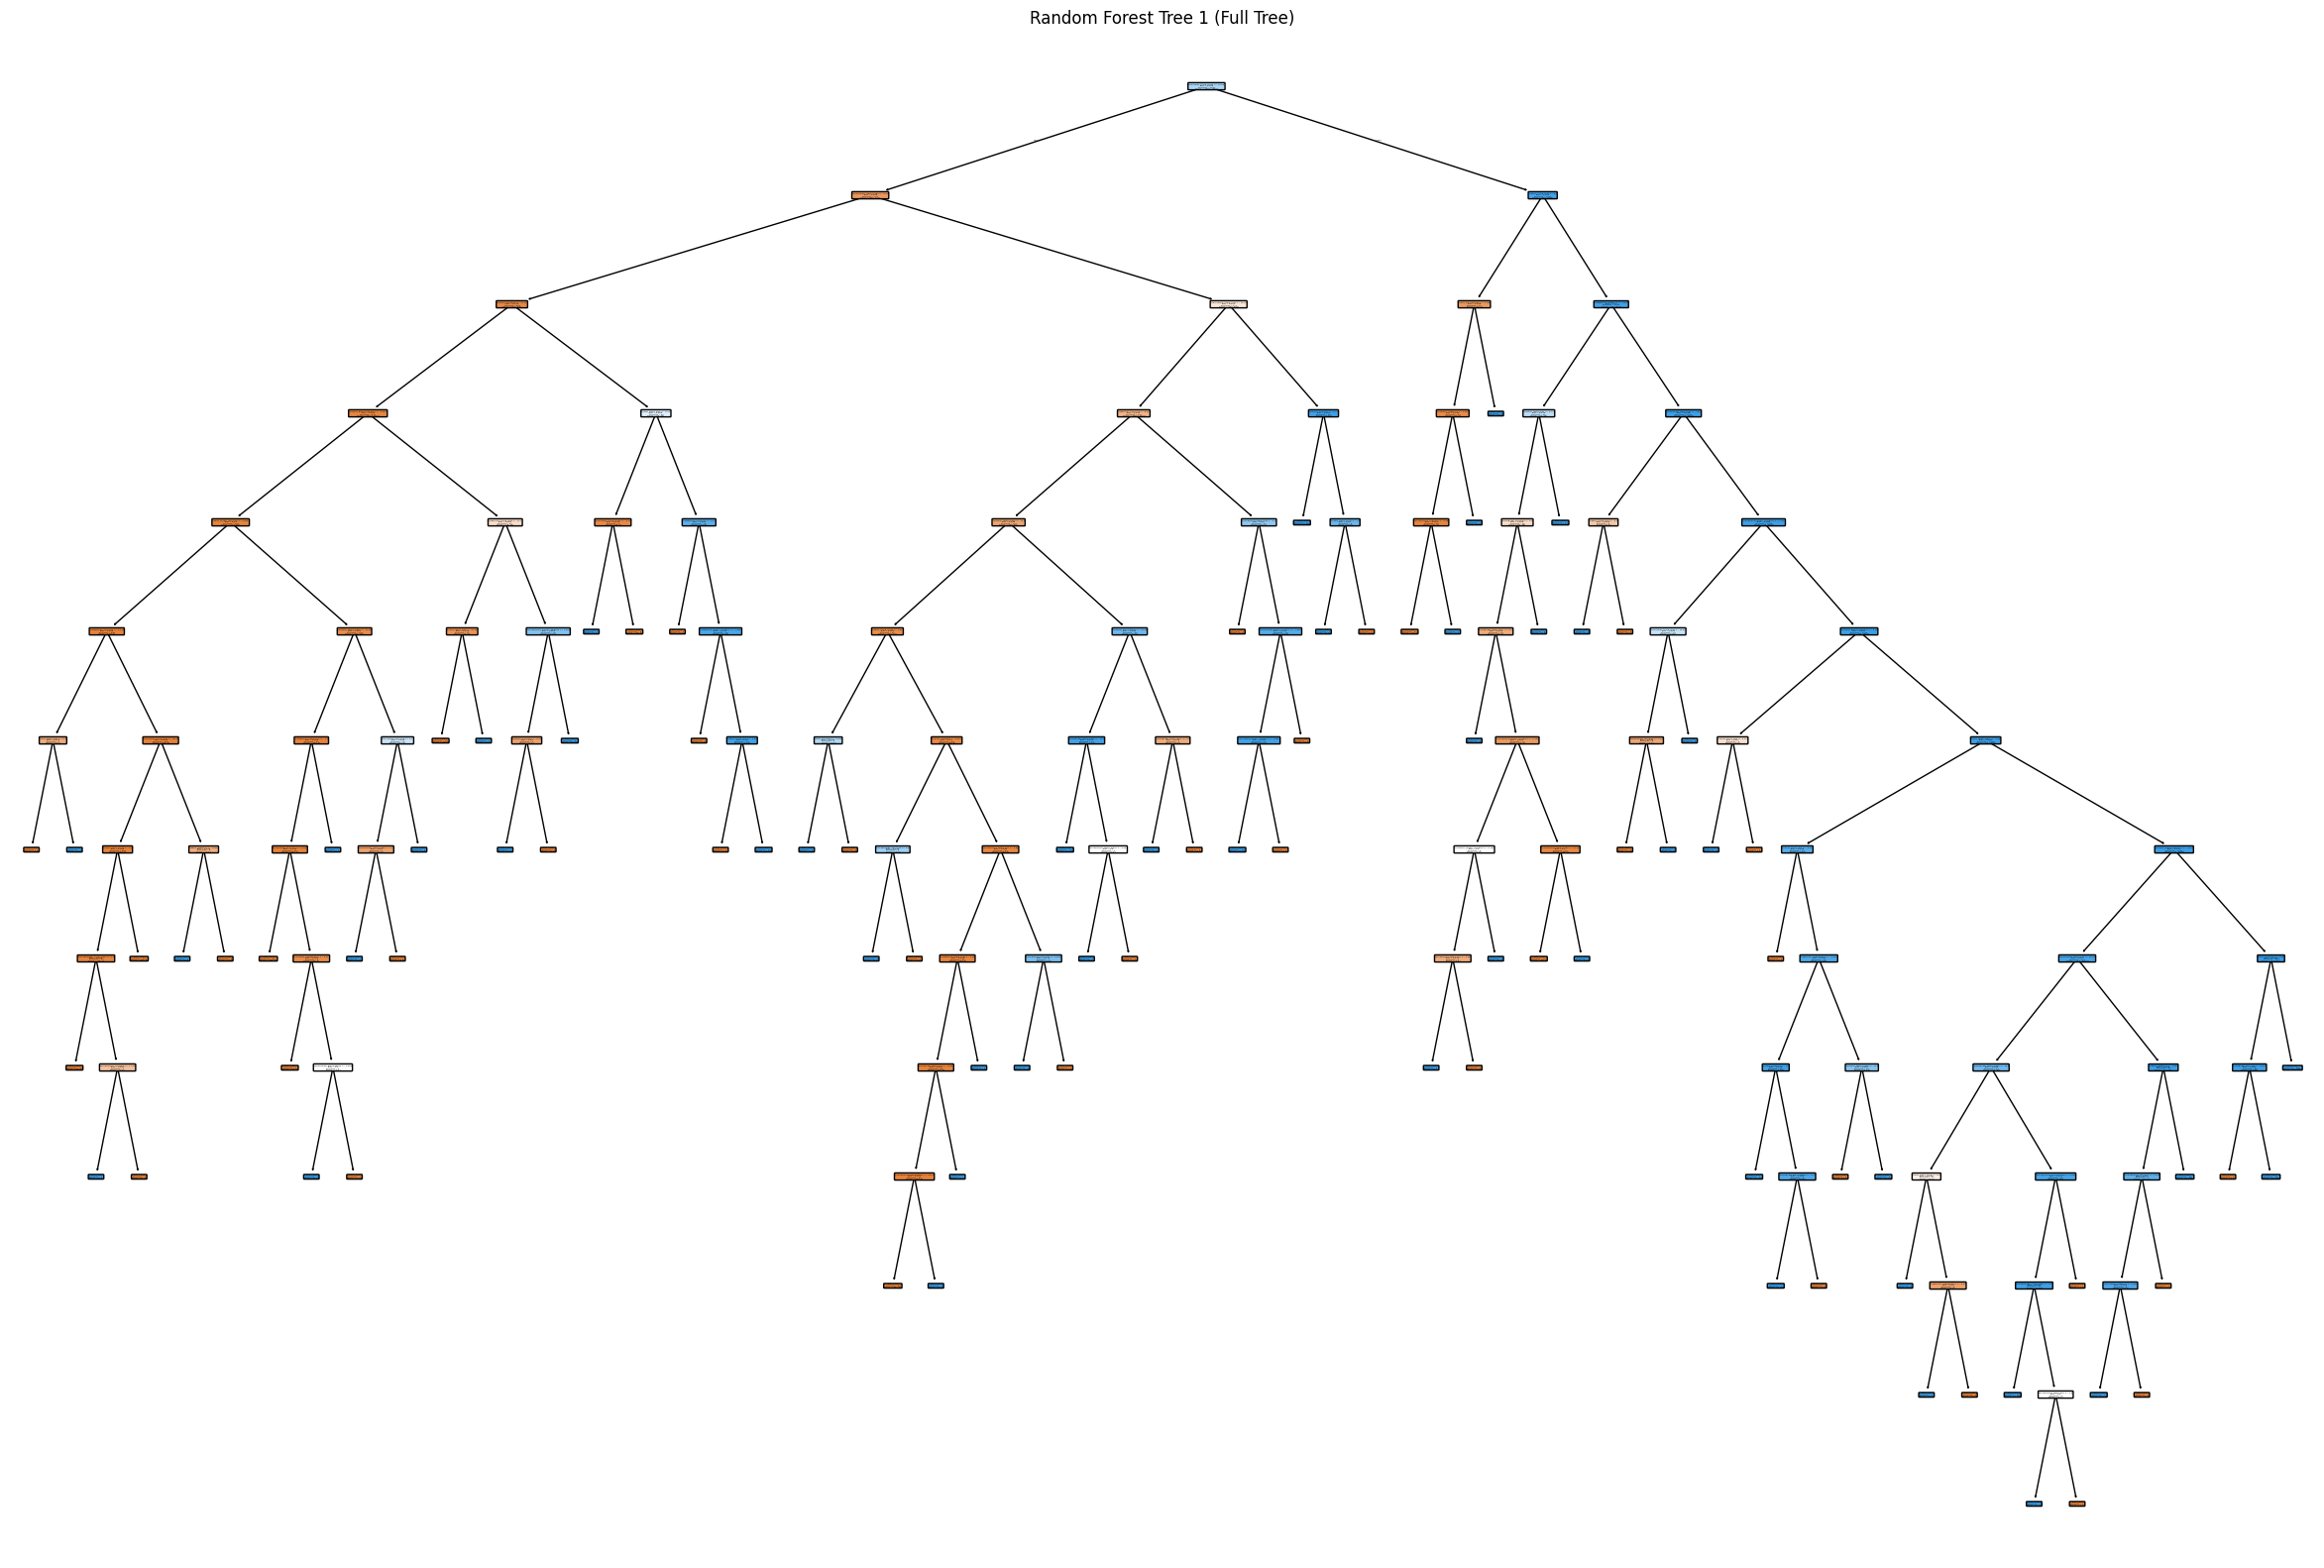

In [51]:
# Model is called clf and is already trained

### FULL
plt.figure(figsize=(30, 20))
plot_tree(clf.estimators_[0], filled=True, rounded=True, feature_names=X.columns)
plt.title("Random Forest Tree 1 (Full Tree)")
plt.show()


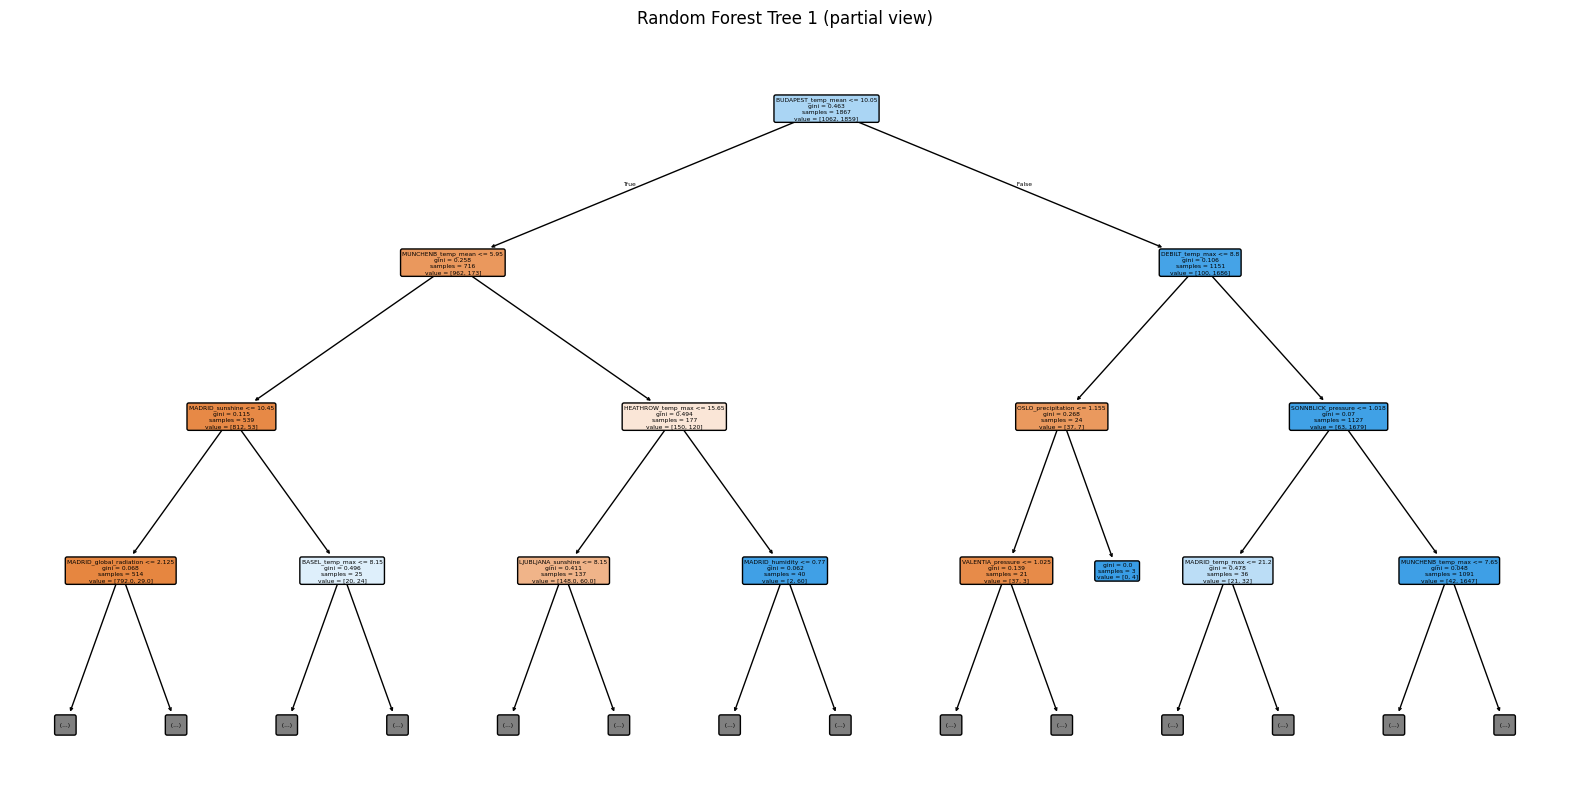

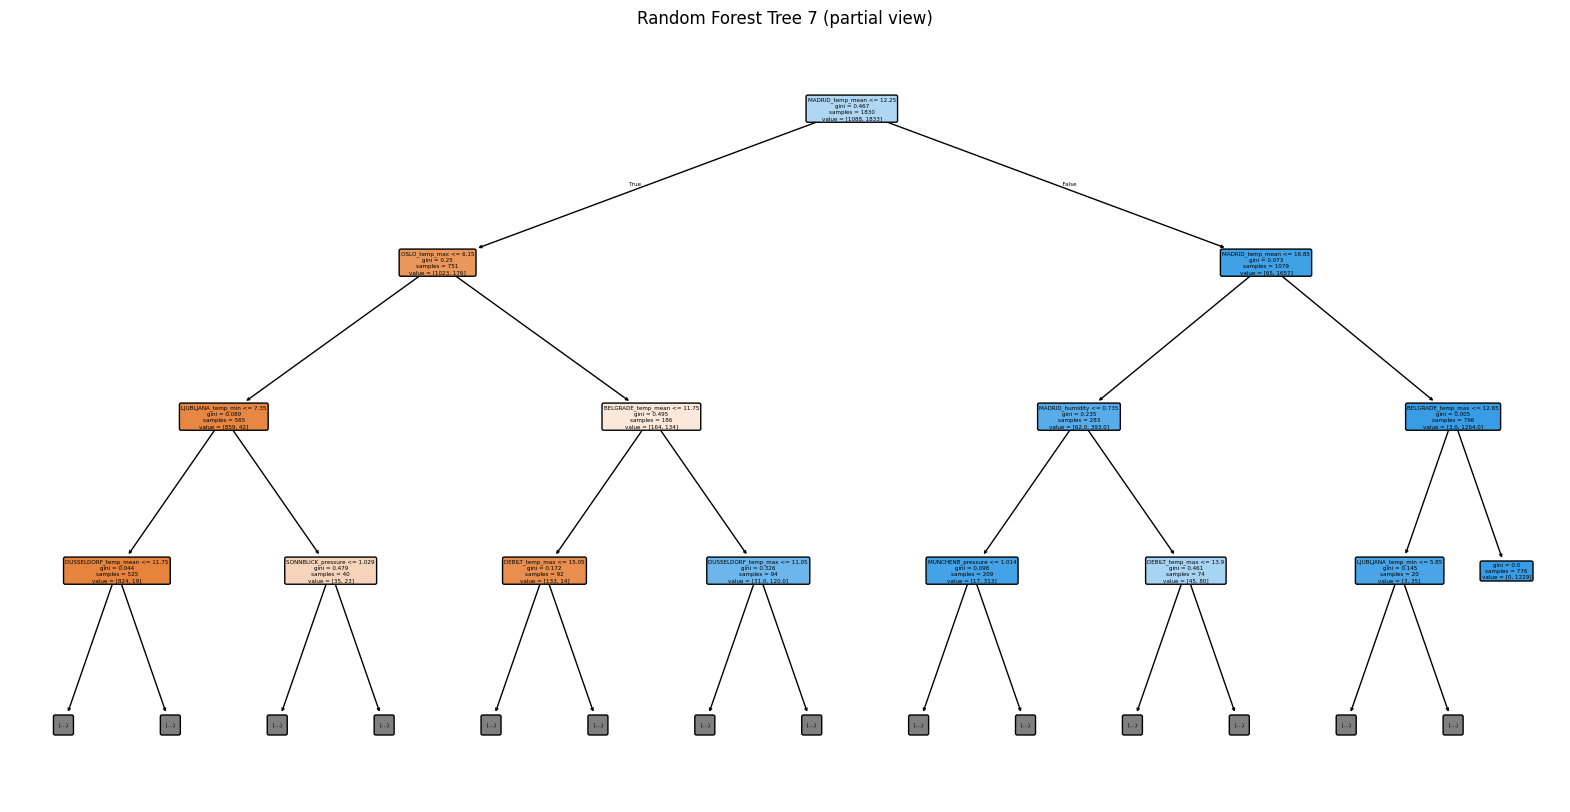

In [53]:
### Partial

# First Decision Tree of the Forest [0]
plt.figure(figsize=(20, 10))
plot_tree(clf.estimators_[0], filled=True, rounded=True, max_depth=3, feature_names=X.columns)
plt.title("Random Forest Tree 1 (partial view)")
plt.show()

# Seventh Decision Tree of the Forest [6]
plt.figure(figsize=(20, 10))
plot_tree(clf.estimators_[6], filled=True, rounded=True, max_depth=3, feature_names=X.columns)
plt.title("Random Forest Tree 7 (partial view)")
plt.show()

# PART II. Random Forests for Each of the Top 3 Weather Stations

In [57]:
weather_df.columns

Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min',
       ...
       'VALENTIA_sunshine', 'VALENTIA_temp_mean', 'VALENTIA_temp_min',
       'VALENTIA_temp_max', 'KASSEL_cloud_cover', 'MUNCHENB_pressure',
       'STOCKHOLM_humidity', 'date', 'year', 'decade'],
      dtype='object', length=140)

In [59]:
weather_df = weather_df.drop(columns=['MONTH'])

# 1. Dataframe Subsetting (3) & Prep for ML

In [60]:
# Top 3 station mappings: code → full name
top_stations = {
    'MAD': 'MADRID',
    'BUD': 'BUDAPEST',
    'LJU': 'LJUBLJANA'
}

# Container to hold all data splits
data_splits = {}

for code, full_name in top_stations.items():
    # 1. Extract weather feature columns for this station (e.g., MADRID_temp_max, etc.)
    weather_cols = [col for col in weather_df.columns if col.startswith(full_name)]
    meta_cols = ['DATE', 'date', 'year', 'decade']  # To keep for possible filtering
    weather_subset = weather_df[meta_cols + weather_cols].copy()

    # 2. Extract pleasantness column for this station
    pleasant_col = f"{full_name}_pleasant_weather"
    pleasant_subset = pleasant_weather[meta_cols + [pleasant_col]].copy()

    # 3. Drop non-feature columns to get X and y
    X = weather_subset.drop(columns=meta_cols)
    y = pleasant_subset[pleasant_col]

    # 4. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

    # 5. Save to dictionary
    data_splits[code] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'full_name': full_name
    }


In [62]:
X.shape

(22950, 9)

In [63]:
y.shape

(22950,)

# 2. 🌲🌲🌲 Loop: Train + Evaluate Random Forests on Top 3 Stations

In [61]:
# Store results
rf_models = {}
rf_accuracies = {}

for code, data in data_splits.items():
    print(f"\n📡 Training Random Forest for {data['full_name']}...")

    # Train model
    clf = RandomForestClassifier(random_state=42)
    clf.fit(data['X_train'], data['y_train'])

    # Evaluate
    accuracy = clf.score(data['X_test'], data['y_test'])

    # Save results
    rf_models[code] = clf
    rf_accuracies[code] = accuracy

    print(f"✅ Accuracy for {data['full_name']}: {accuracy:.3f}")



📡 Training Random Forest for MADRID...
✅ Accuracy for MADRID: 1.000

📡 Training Random Forest for BUDAPEST...
✅ Accuracy for BUDAPEST: 1.000

📡 Training Random Forest for LJUBLJANA...
✅ Accuracy for LJUBLJANA: 1.000


### 🔍 Evaluation & Notes: Accuracy & Determinism
> Though the Random Forest achieved ~97% accuracy on the full dataset, it reached 100% accuracy when trained individually on each of the Top 3 stations. A previous supervised learning model (a single decision tree) also returned 100% on another station (Oslo), suggesting that:

- The pleasant/unpleasant classification task is highly deterministic.

- A single decision tree can easily reverse-engineer the rules when focused on just one station.

> In contrast, the full-dataset model collapsed pleasantness into a single binary label per day, across 15 stations, to identify which stations contribute most to pleasant weather overall. This setup introduced:

- A large number of features (15 stations × 9 features each),

- A noisy label with no clear origin or alignment, and

- Conflicting signals from diverse climate regions on the same day.

> As a result, the model couldn't isolate a clear decision boundary, leading to a (still solid) ~97% accuracy — but not perfect.

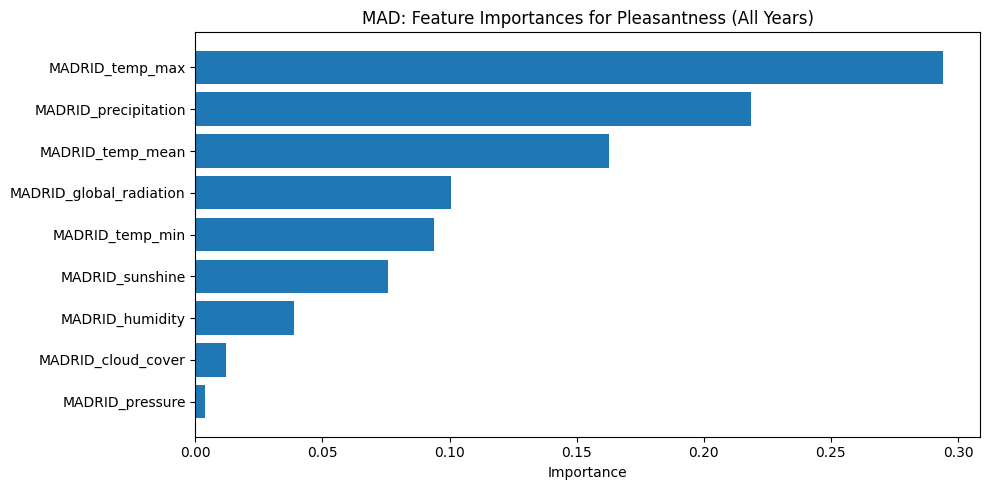

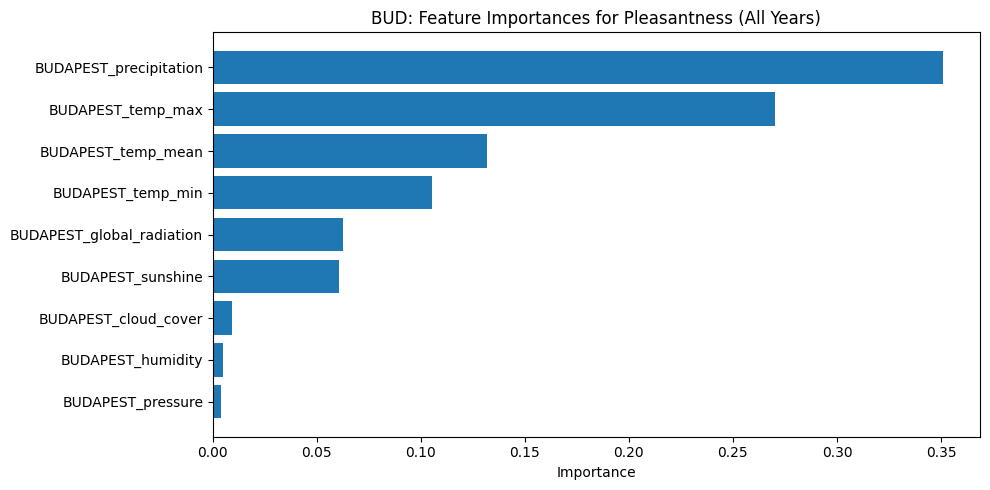

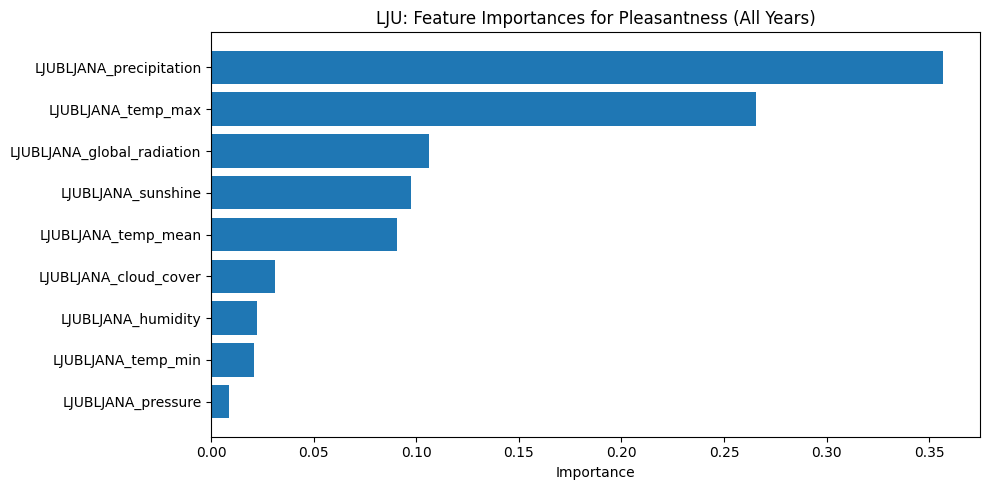

In [70]:
top3 = ['MAD', 'BUD', 'LJU']

for station in top3:
    clf = rf_models[station]
    features = data_splits[station]['X_train'].columns
    importances = clf.feature_importances_

    # Sort features and importances in descending order
    sorted_idx = importances.argsort()[::-1]
    sorted_features = features[sorted_idx]
    sorted_importances = importances[sorted_idx]

    plt.figure(figsize=(10, 5))
    plt.barh(sorted_features, sorted_importances)
    plt.title(f"{station}: Feature Importances for Pleasantness (All Years)")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


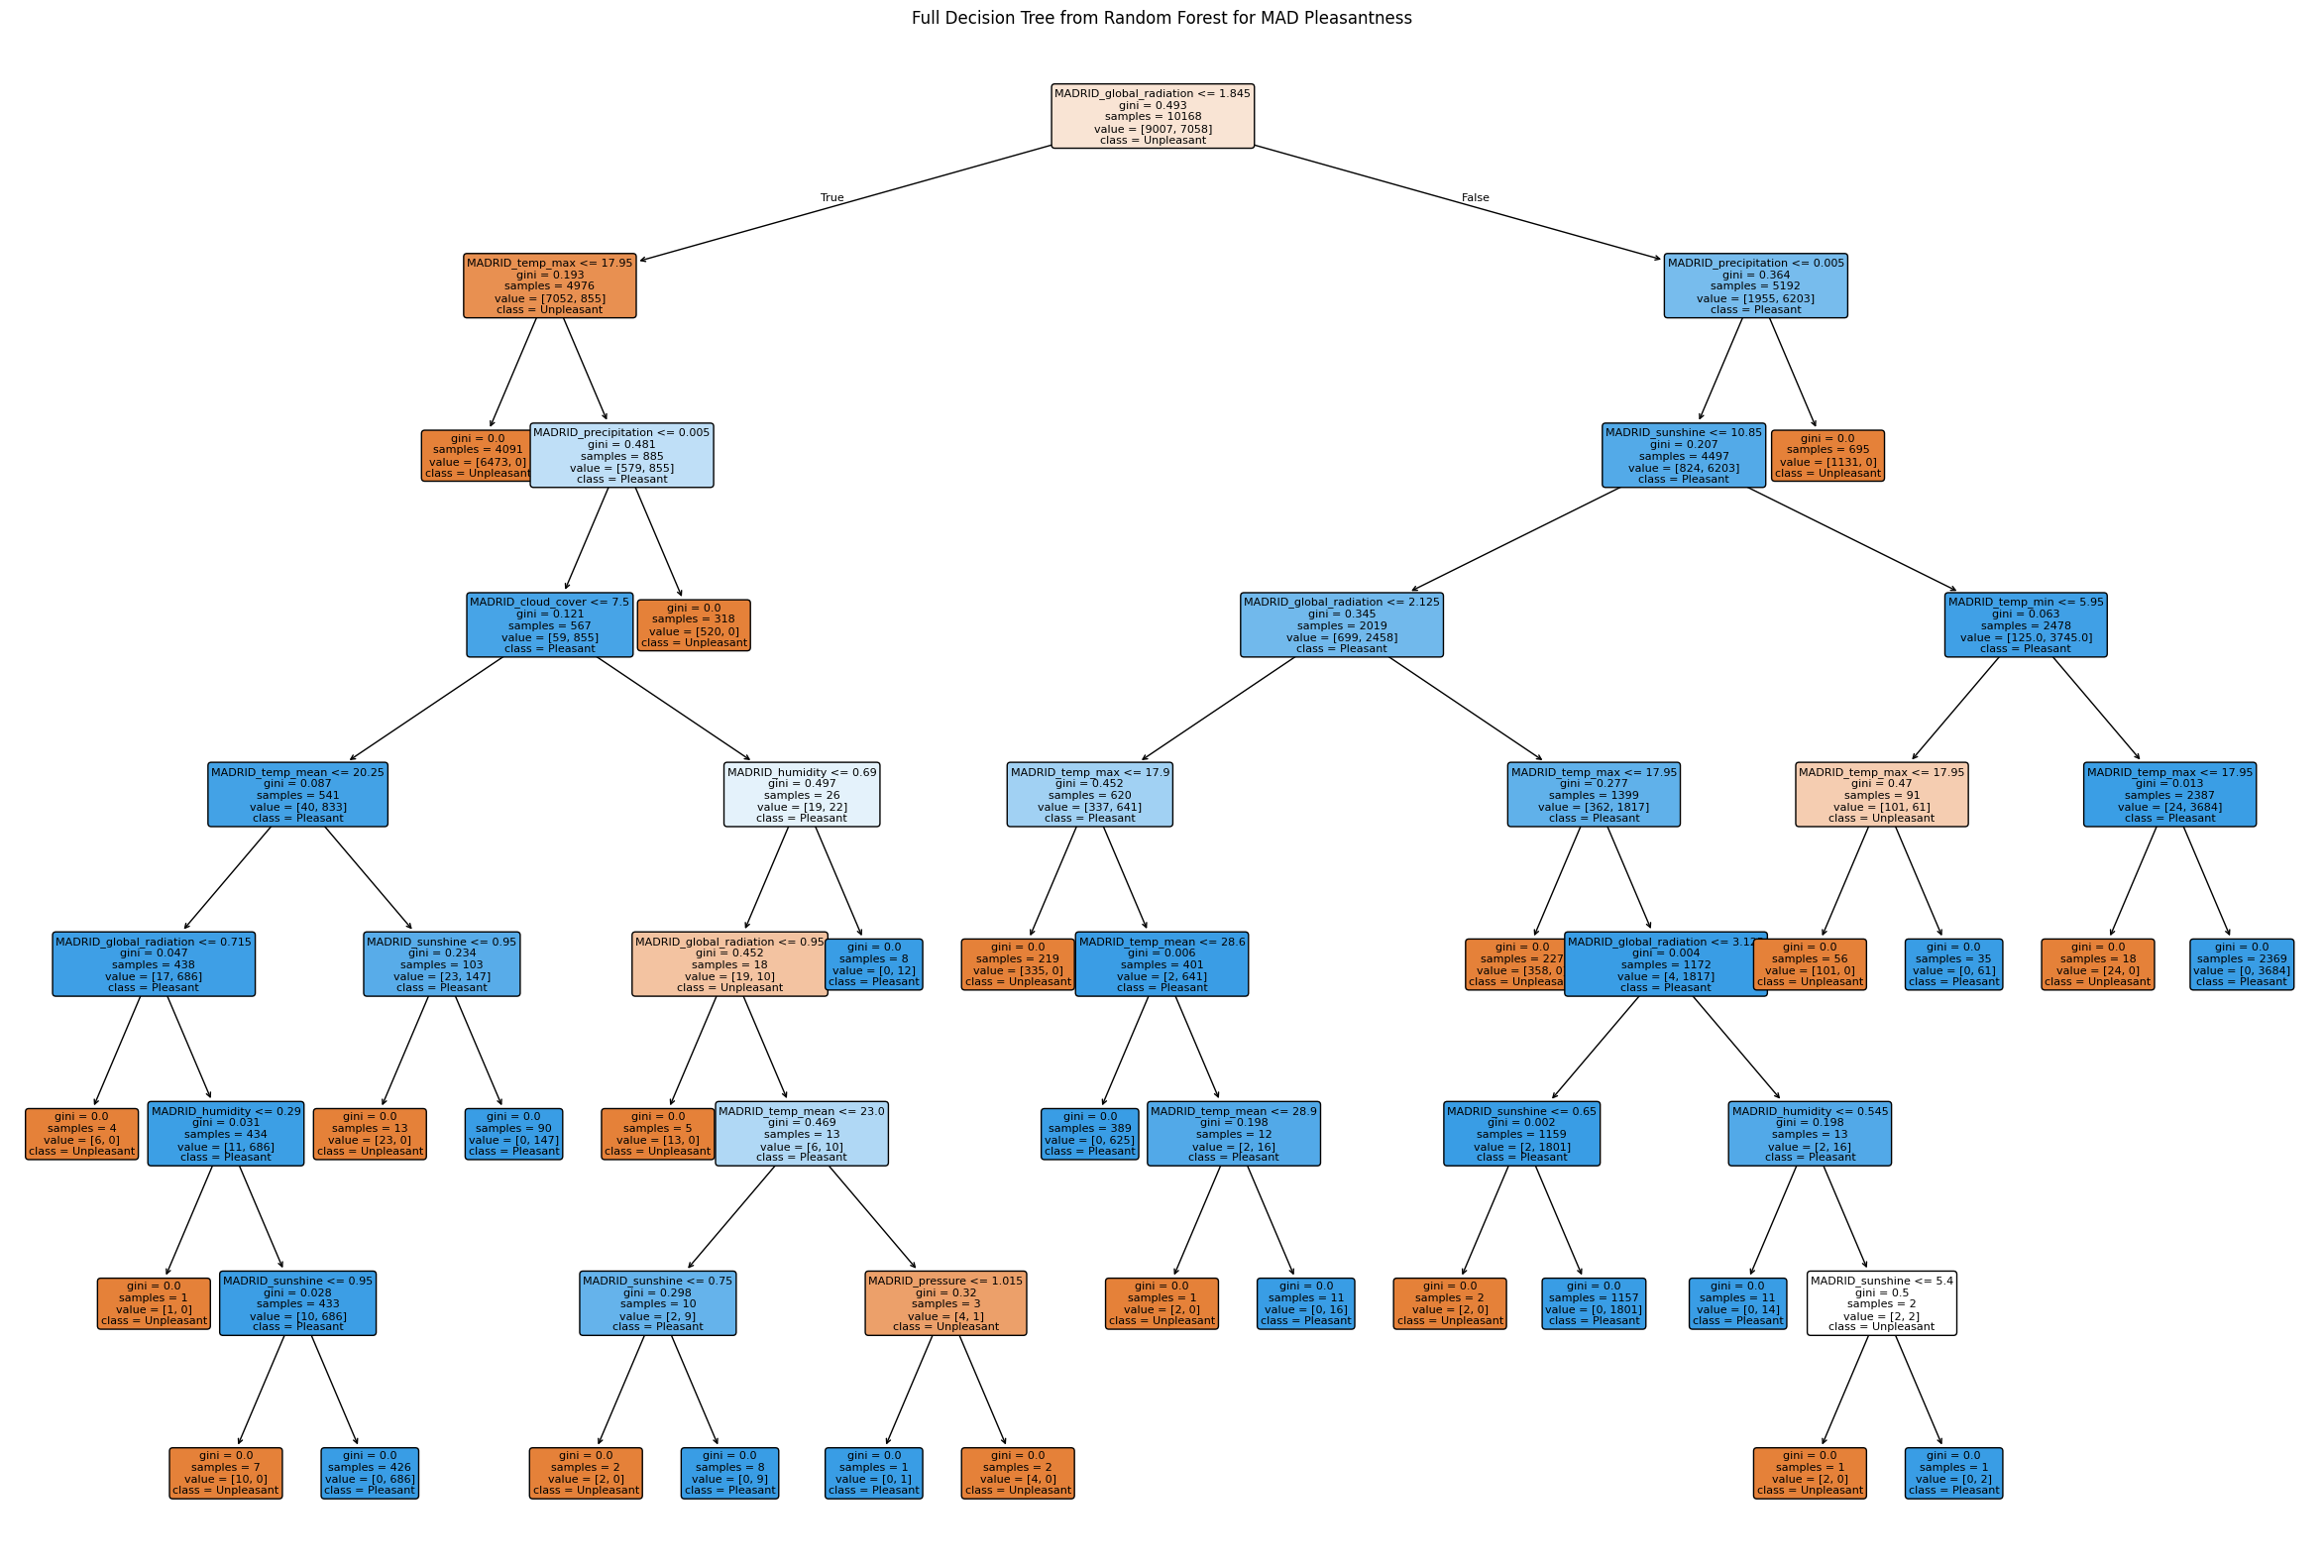

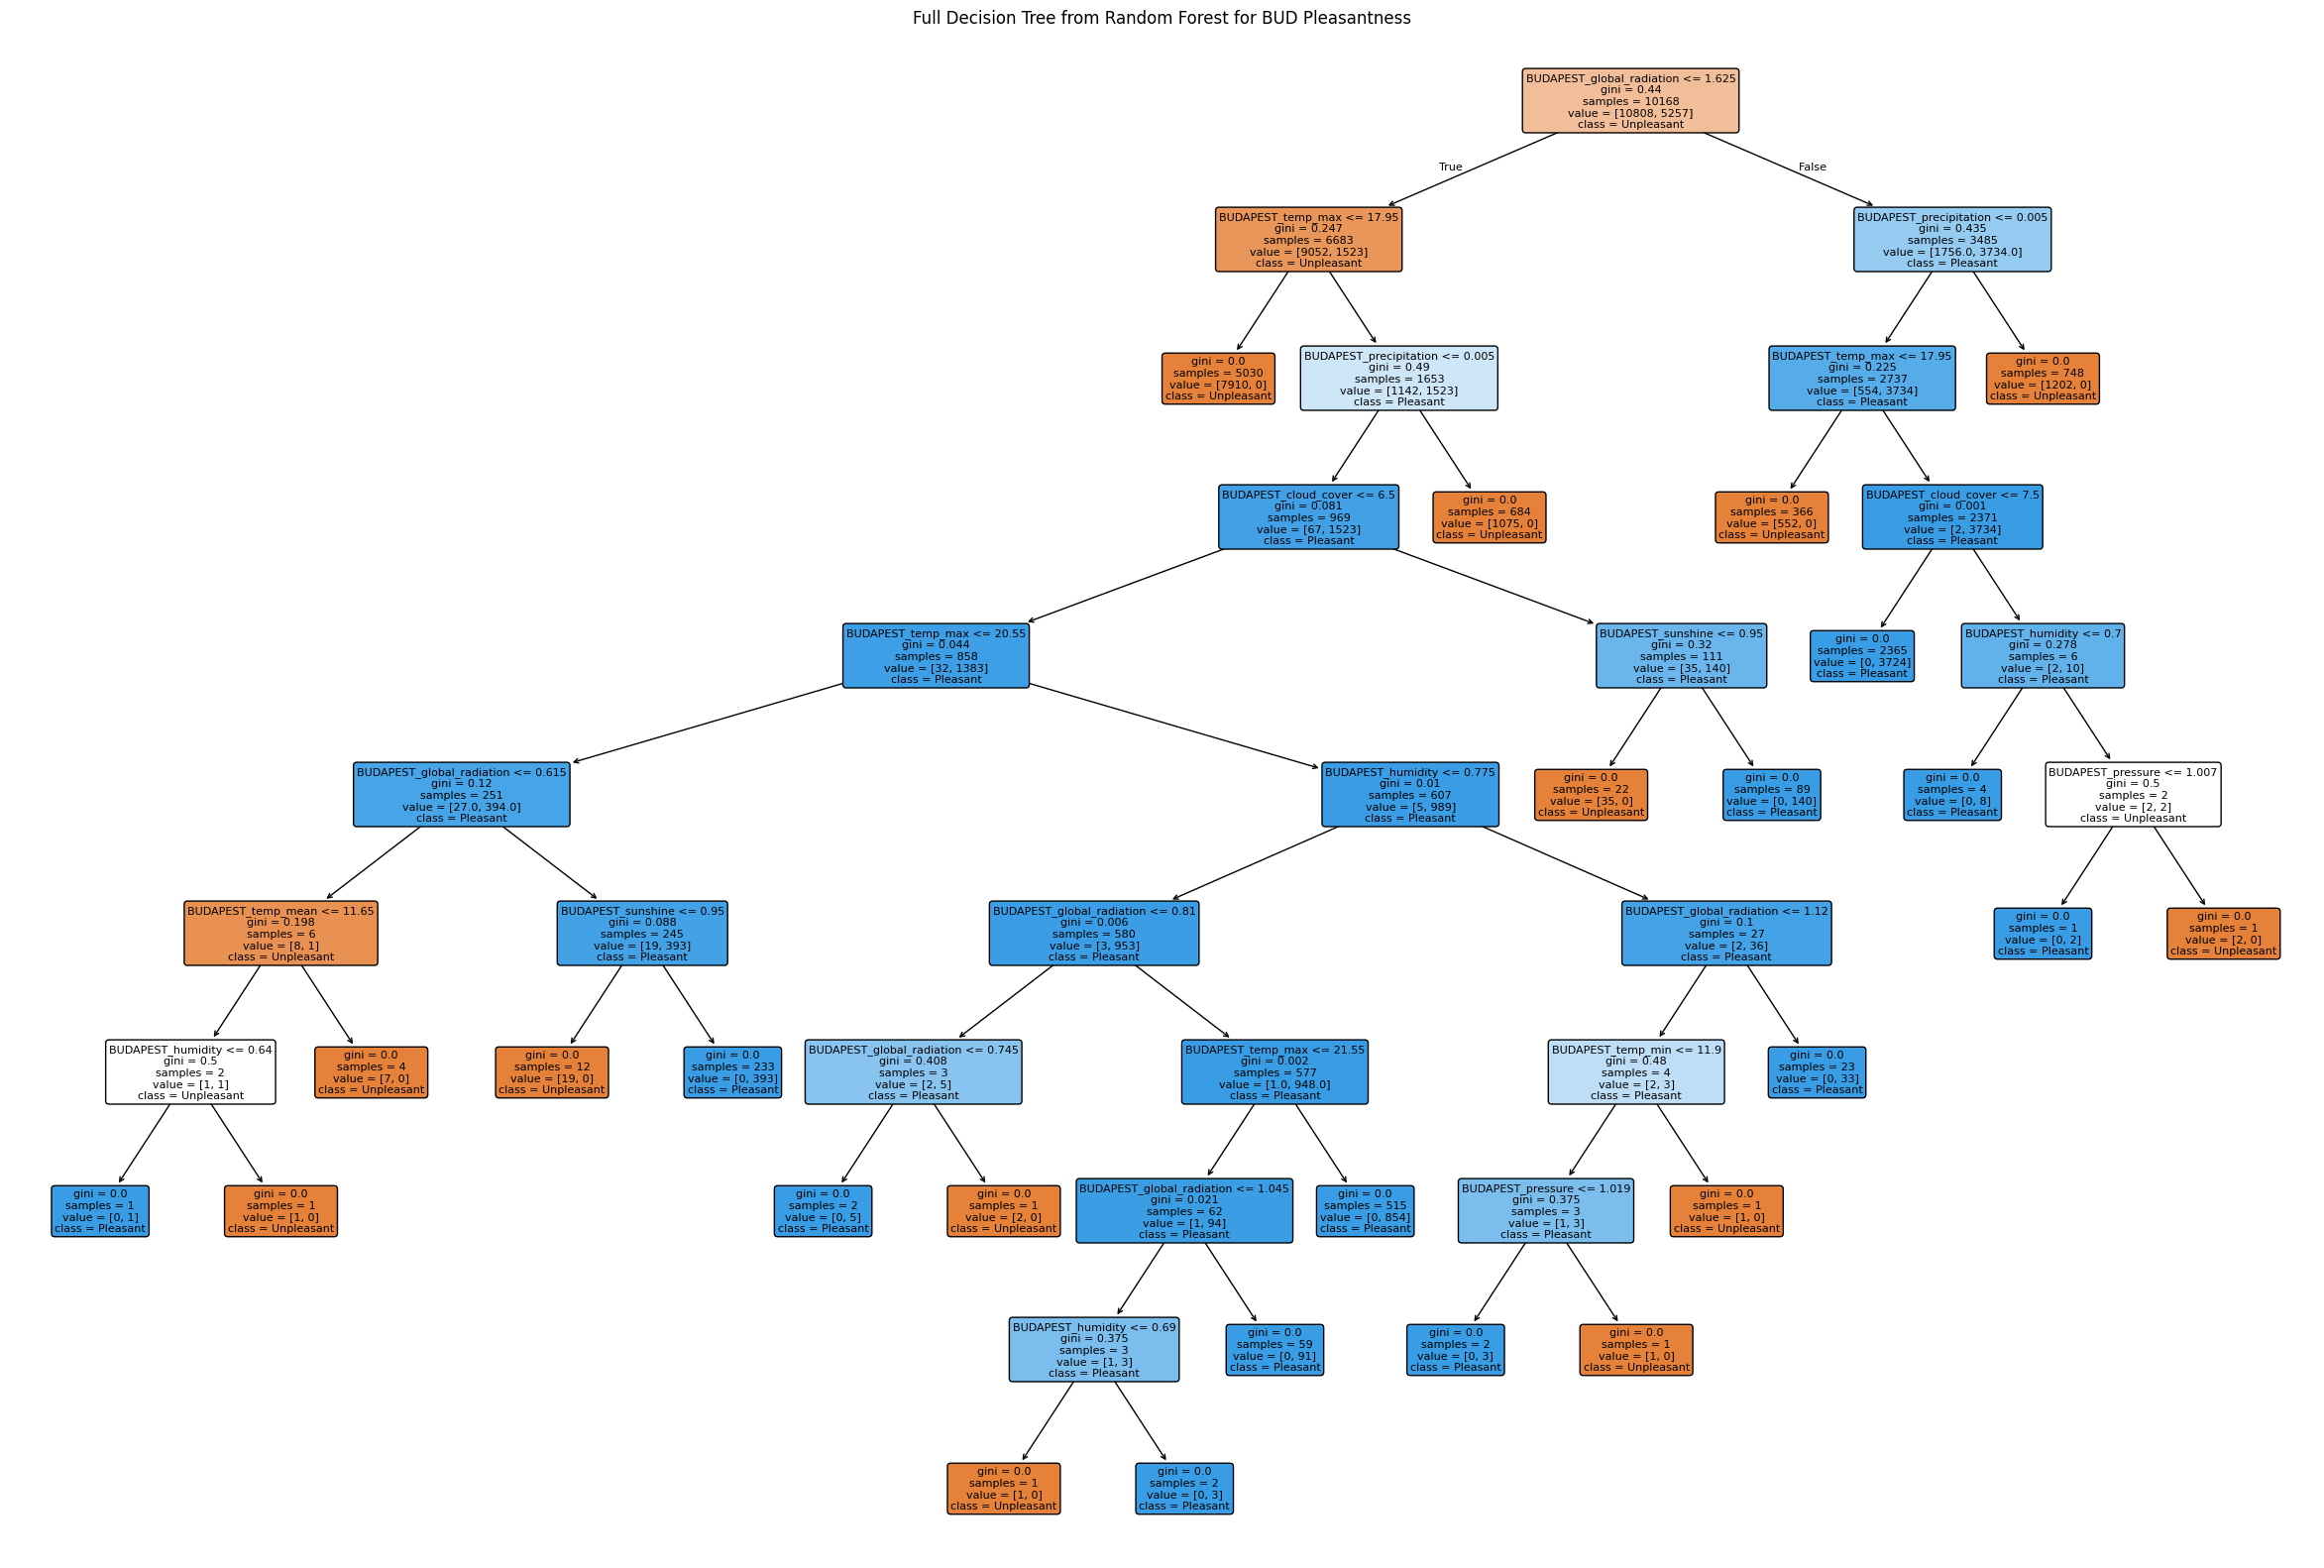

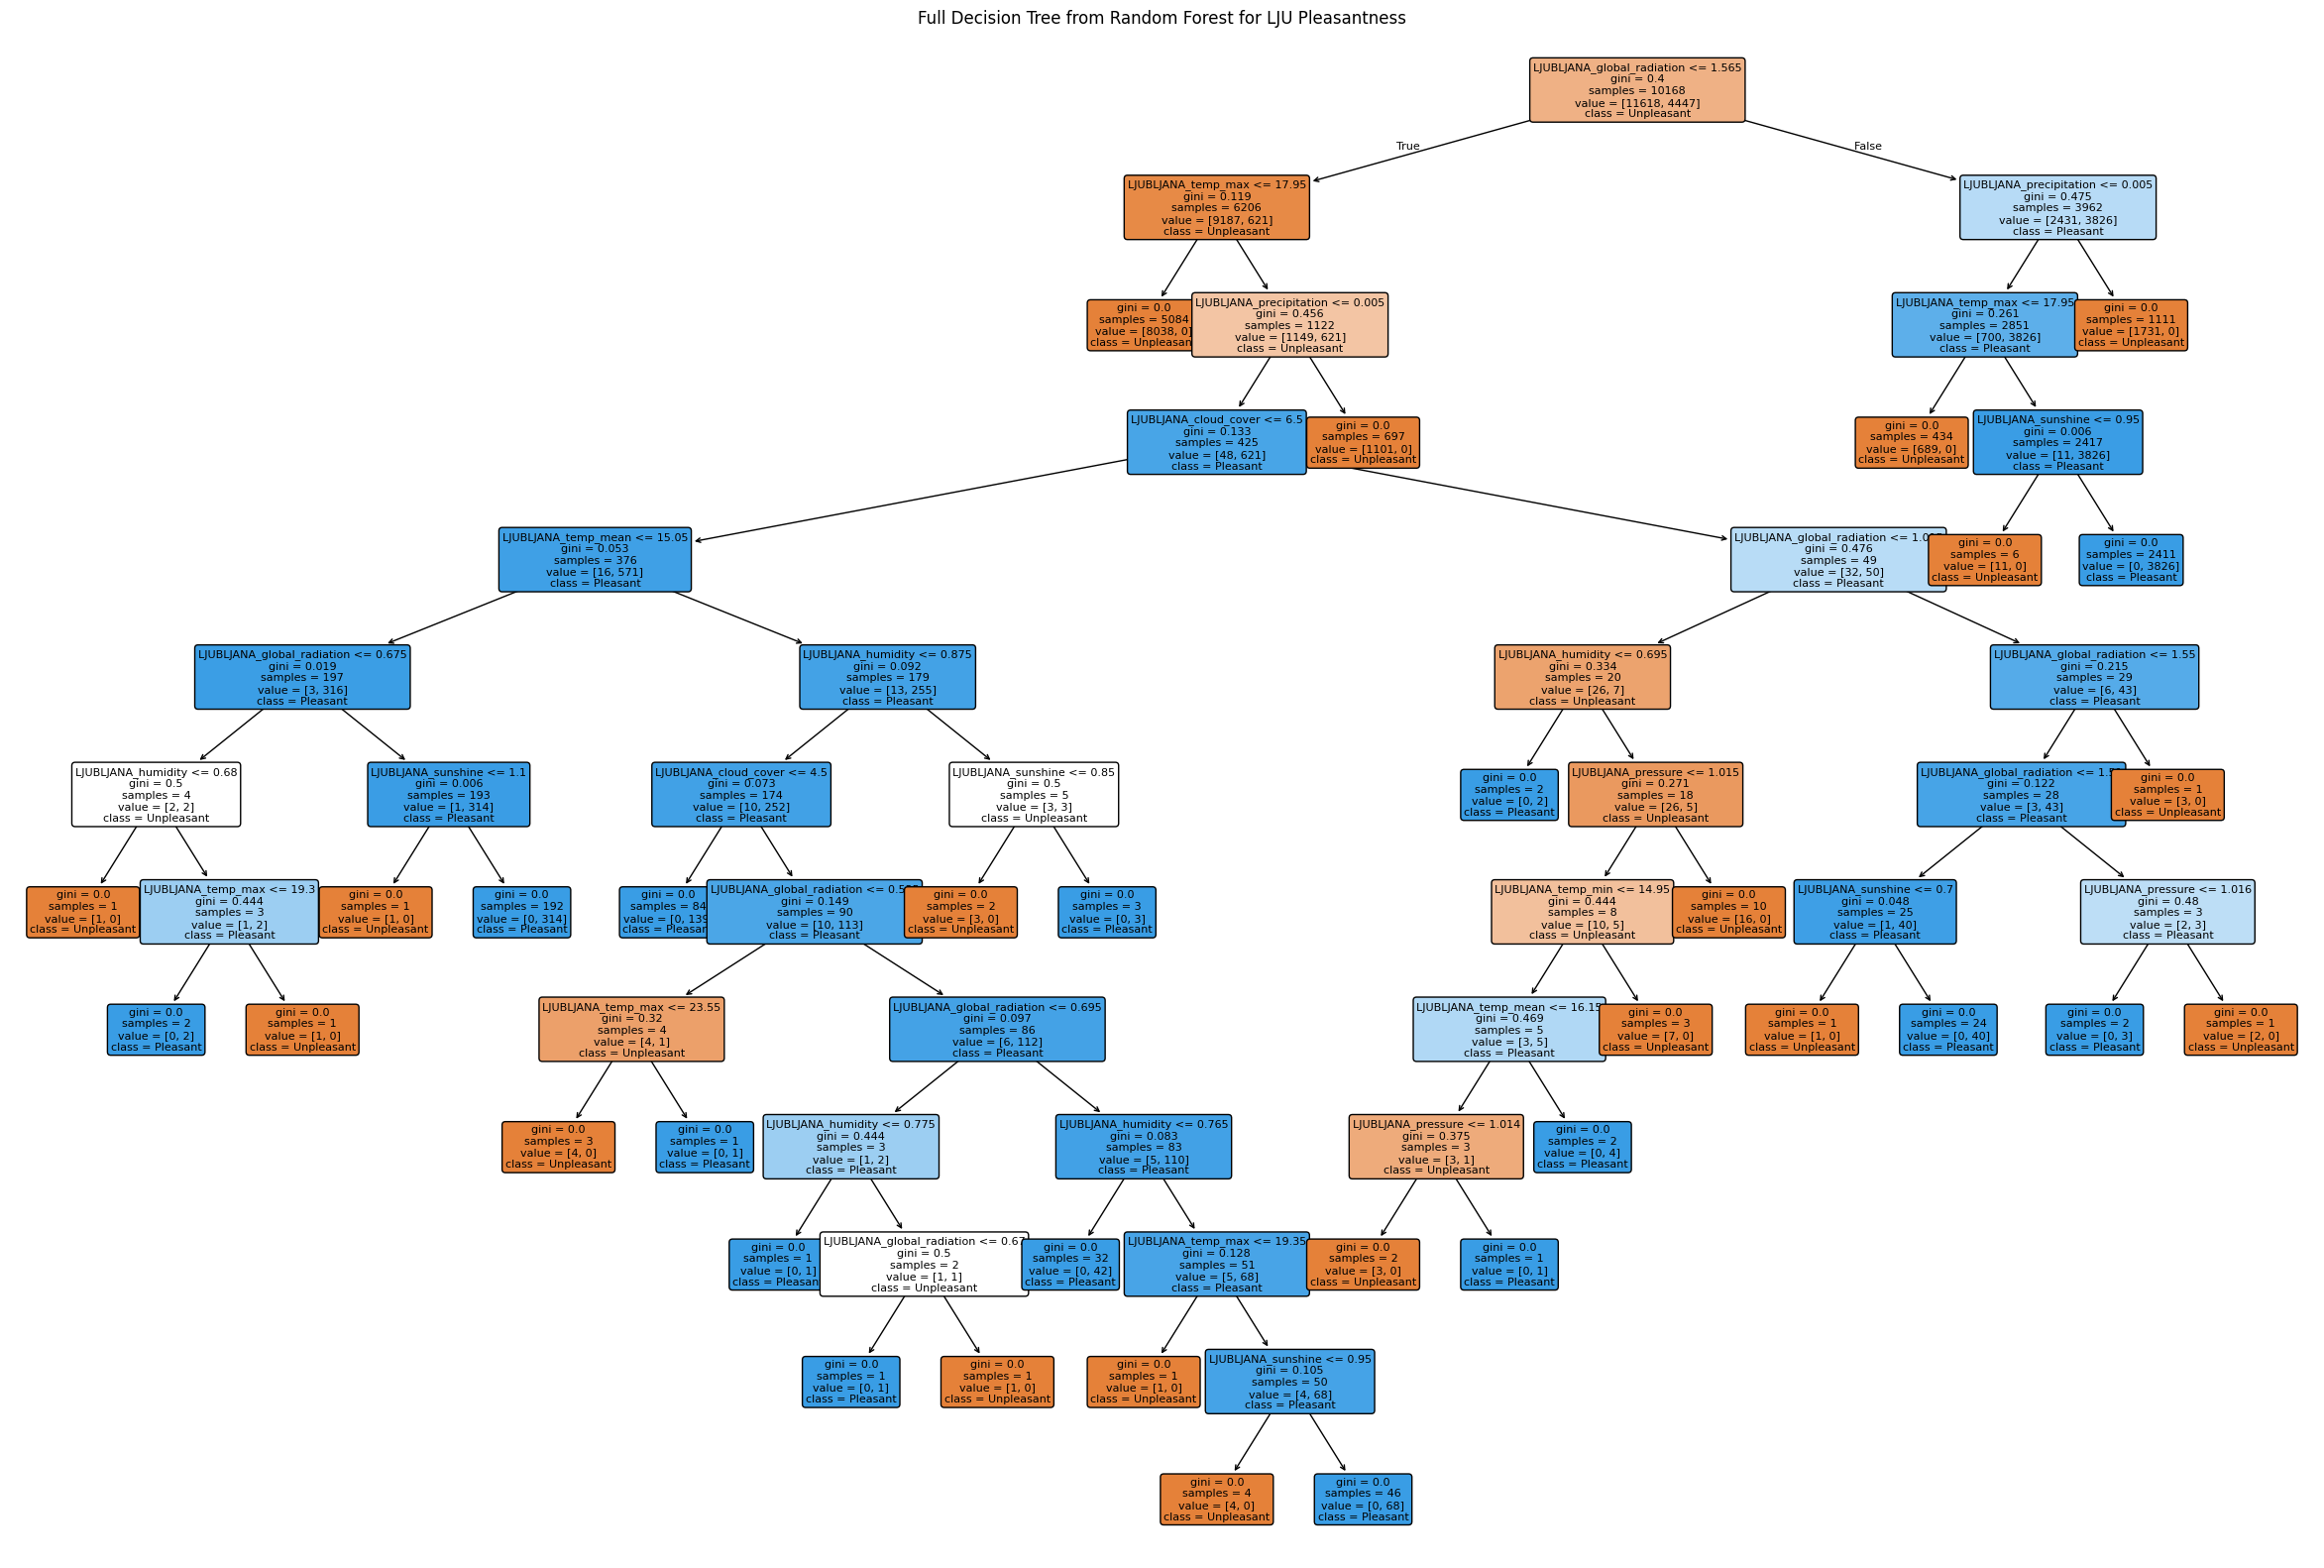

In [71]:
for station in top3:
    clf = rf_models[station]
    features = data_splits[station]['X_train'].columns

    plt.figure(figsize=(30, 20))  # Large size for full tree
    plot_tree(
        clf.estimators_[0],  # Plot first tree of the forest
        filled=True,
        rounded=True,
        feature_names=features,
        class_names=['Unpleasant', 'Pleasant'],
        fontsize=8
    )
    plt.title(f"Full Decision Tree from Random Forest for {station} Pleasantness")
    plt.show()


# PART III. Weather 'Fingerprint' for All Stations

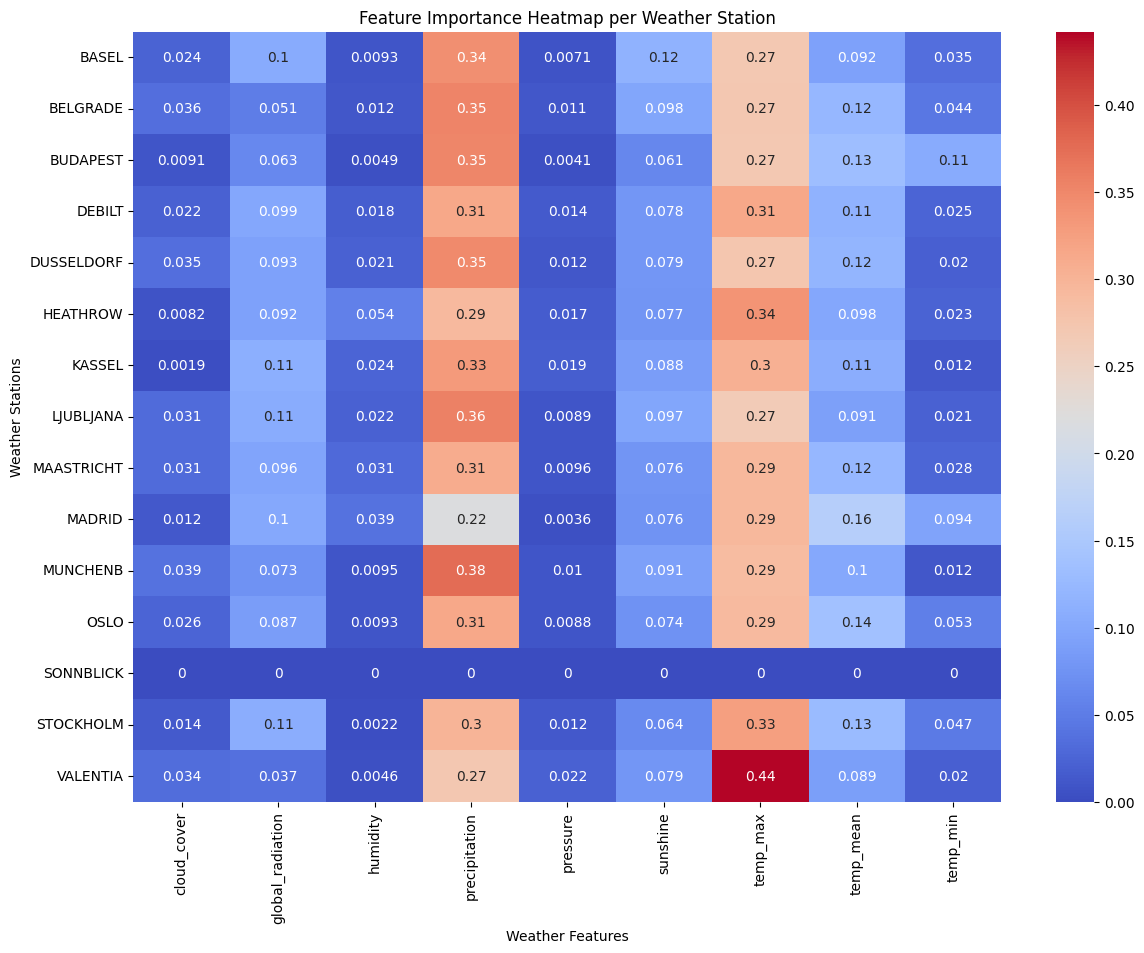

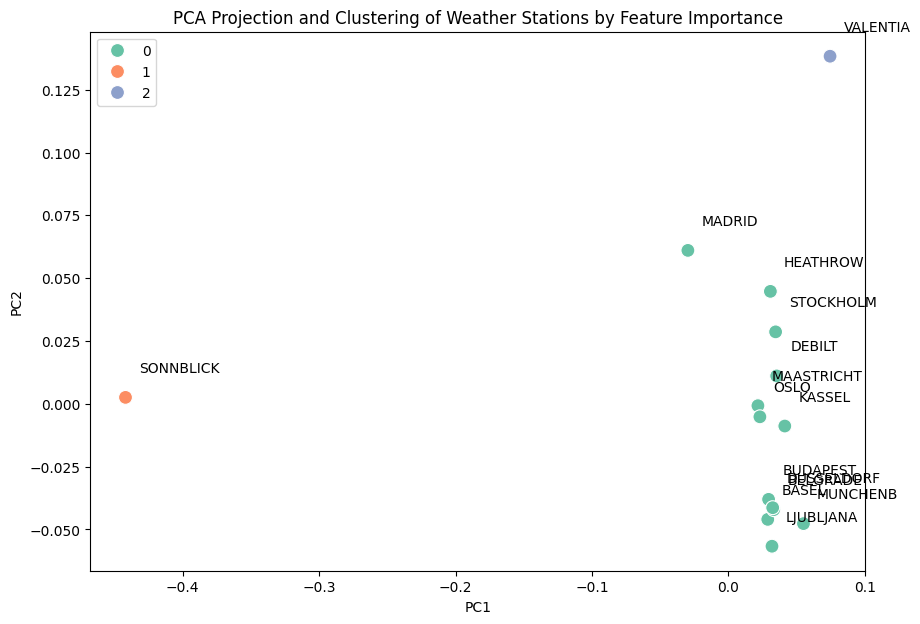

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Get all station codes
all_stations = sorted({col.split('_')[0] for col in weather_df.columns if '_' in col and col.split('_')[0] != 'DATE'})

# Step 2: Train RF per station and store normalized feature importances
all_station_importances = {}

for station in all_stations:
    # Get weather feature columns for this station
    weather_cols = [col for col in weather_df.columns if col.startswith(station)]
    meta_cols = ['DATE', 'date', 'year', 'decade']
    weather_subset = weather_df[meta_cols + weather_cols].copy()

    # Get corresponding pleasantness column
    pleasant_col = f"{station}_pleasant_weather"
    if pleasant_col not in pleasant_weather.columns:
        print(f"Skipping {station}, no pleasantness column.")
        continue
    pleasant_subset = pleasant_weather[meta_cols + [pleasant_col]].copy()

    # Prepare features (X) and target (y)
    X = weather_subset.drop(columns=meta_cols)
    y = pleasant_subset[pleasant_col]

    # Rename features to drop station prefix (e.g., MADRID_temp_max → temp_max)
    X.columns = [col.split('_', 1)[1] for col in X.columns]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

    # Train RF
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Save importance as Series (feature names as index)
    feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
    all_station_importances[station] = feature_importances

# Step 3: Create tidy DataFrame, fill in 0 for any missing features
importance_df = pd.DataFrame(all_station_importances).T.fillna(0)

# Step 4: Visualize as heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(importance_df, cmap='coolwarm', annot=True)
plt.title('Feature Importance Heatmap per Weather Station')
plt.xlabel('Weather Features')
plt.ylabel('Weather Stations')
plt.show()

# Step 5: PCA + Clustering
pca = PCA(n_components=2)
pca_results = pca.fit_transform(importance_df)

cluster = AgglomerativeClustering(n_clusters=3)
clusters = cluster.fit_predict(importance_df)

importance_df['cluster'] = clusters

# Step 6: Plot PCA projection
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_results[:, 0], y=pca_results[:, 1], hue=clusters, palette='Set2', s=100)
for i, station in enumerate(importance_df.index):
    plt.text(pca_results[i, 0] + 0.01, pca_results[i, 1] + 0.01, station)
plt.title('PCA Projection and Clustering of Weather Stations by Feature Importance')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


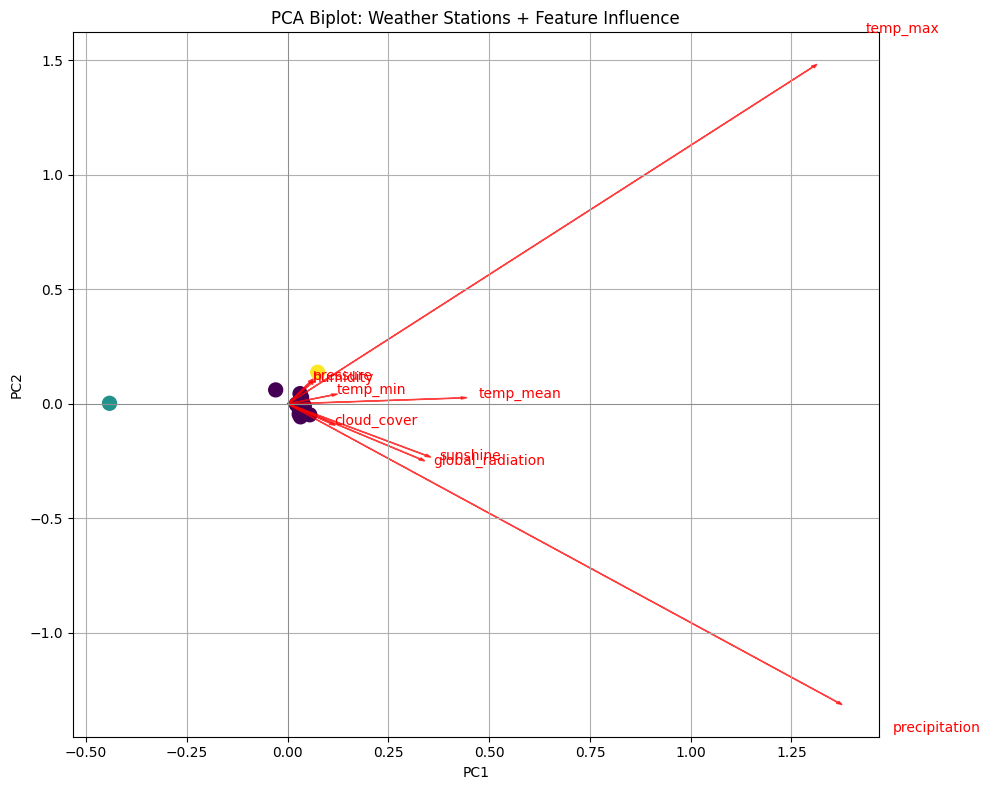

In [78]:
import matplotlib.pyplot as plt

# Make sure to exclude 'cluster' column before plotting arrows
feature_names = importance_df.columns.drop('cluster')

plt.figure(figsize=(10, 8))

# Scatter plot of stations colored by cluster
scatter = plt.scatter(pca_results[:, 0], pca_results[:, 1], c=importance_df['cluster'], cmap='viridis', s=100)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot: Weather Stations + Feature Influence')

# Plot arrows for each feature to show loadings (scaled for visibility)
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0,
              pca.components_[0, i]*2,
              pca.components_[1, i]*2,
              color='r', alpha=0.7, head_width=0.01)
    plt.text(pca.components_[0, i]*2.2,
             pca.components_[1, i]*2.2,
             feature, color='r', fontsize=10)

plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()


In [79]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=importance_df.columns[:-1],  # Exclude 'cluster'
    index=['PC1', 'PC2']
)

print(pca_components.T)


                       PC1       PC2
cloud_cover       0.053101 -0.042395
global_radiation  0.164066 -0.120224
humidity          0.028673  0.044103
precipitation     0.682271 -0.651795
pressure          0.027921  0.047897
sunshine          0.171339 -0.112338
temp_max          0.651590  0.735880
temp_mean         0.215005  0.012928
temp_min          0.054899  0.019143


### **Slide: PCA + Clustering of Weather “Fingerprints”**

To better understand the overall patterns in how different weather stations determine “pleasantness,” we applied PCA to the feature importance scores from each station’s Random Forest model.

This transformation reduced the original 9-dimensional feature space (e.g., temp\_max, precipitation, etc.) into 2 principal components, enabling us to visualize each station as a point in 2D space. Each point represents that station’s unique “weather recipe fingerprint” — a condensed summary of which weather features mattered most and how strongly.

We asked:
**“Which stations rely on similar patterns of weather features to predict pleasantness?”**

**Key observations:**

* **Sonnblick** and **Valentia** form their own isolated clusters. This is expected — Sonnblick had zero pleasant days, and Valentia had very limited data.
* Within the main cluster, **Madrid** stands out slightly, positioned lower along PC1. This aligns with its **unusually low importance for precipitation**, in contrast to most other stations where it ranked highly.
* The rest of the stations group tightly, indicating they share a broadly similar model of pleasantness — heavily influenced by **precipitation** and **temp\_max**.

But this shared fingerprint **doesn’t necessarily reflect similar weather patterns** across the locations. Instead, it likely reflects the **structure of the classification rules** used to define pleasantness in the first place. In essence, the models are learning (and possibly mirroring) the thresholds already embedded in how we labeled the data.

**Important caution:**
This means the high classification accuracy may partly stem from circular logic — the Random Forests are good at reverse-engineering the rule-based thresholds, especially when they’re cleanly separable (e.g., "pleasant = temp > 20°C and precipitation = 0 mm").

We might gain **less tautological** insights by looking at *non-rule-defined metrics* or **proxy variables** like sunshine or cloud cover — but these showed relatively low influence in both the feature importances and PCA loadings, suggesting limited predictive power within this framework.
